<a href="https://colab.research.google.com/github/ngjingwen-0320/5002CMD-Assignment/blob/main/Bank_Marketing_Dataset_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv("bank-full.csv", sep=";")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [28]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [29]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 45211
Number of columns: 17


In [30]:
print(df.columns.tolist())

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [31]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [33]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [34]:
df.describe(include="object")

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


In [35]:
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

missing_summary

,Missing Count,Missing Percentage
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0


In [36]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [37]:
target_counts = df["y"].value_counts()
target_percentages = df["y"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages
})

target_summary

,Count,Percentage
y,,
no,39922,88.30152
yes,5289,11.69848


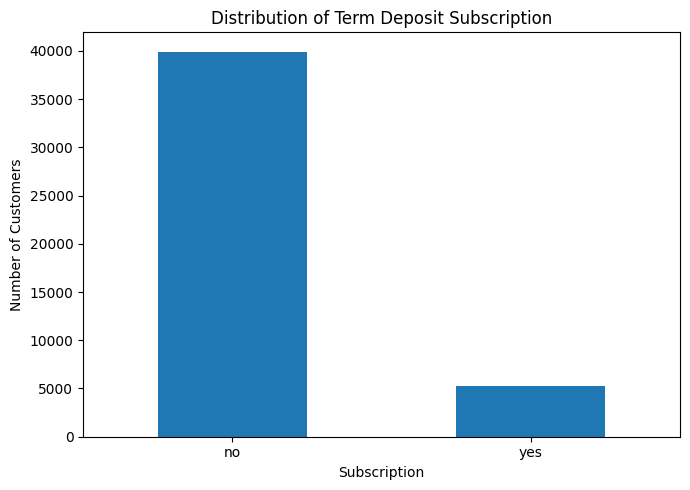

In [38]:
plt.figure(figsize=(7, 5))

df["y"].value_counts().plot(kind="bar")

plt.title("Distribution of Term Deposit Subscription")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [39]:
numerical_cols = df.select_dtypes(include=np.number).columns

print("Numerical variables:")
print(numerical_cols.tolist())

Numerical variables:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


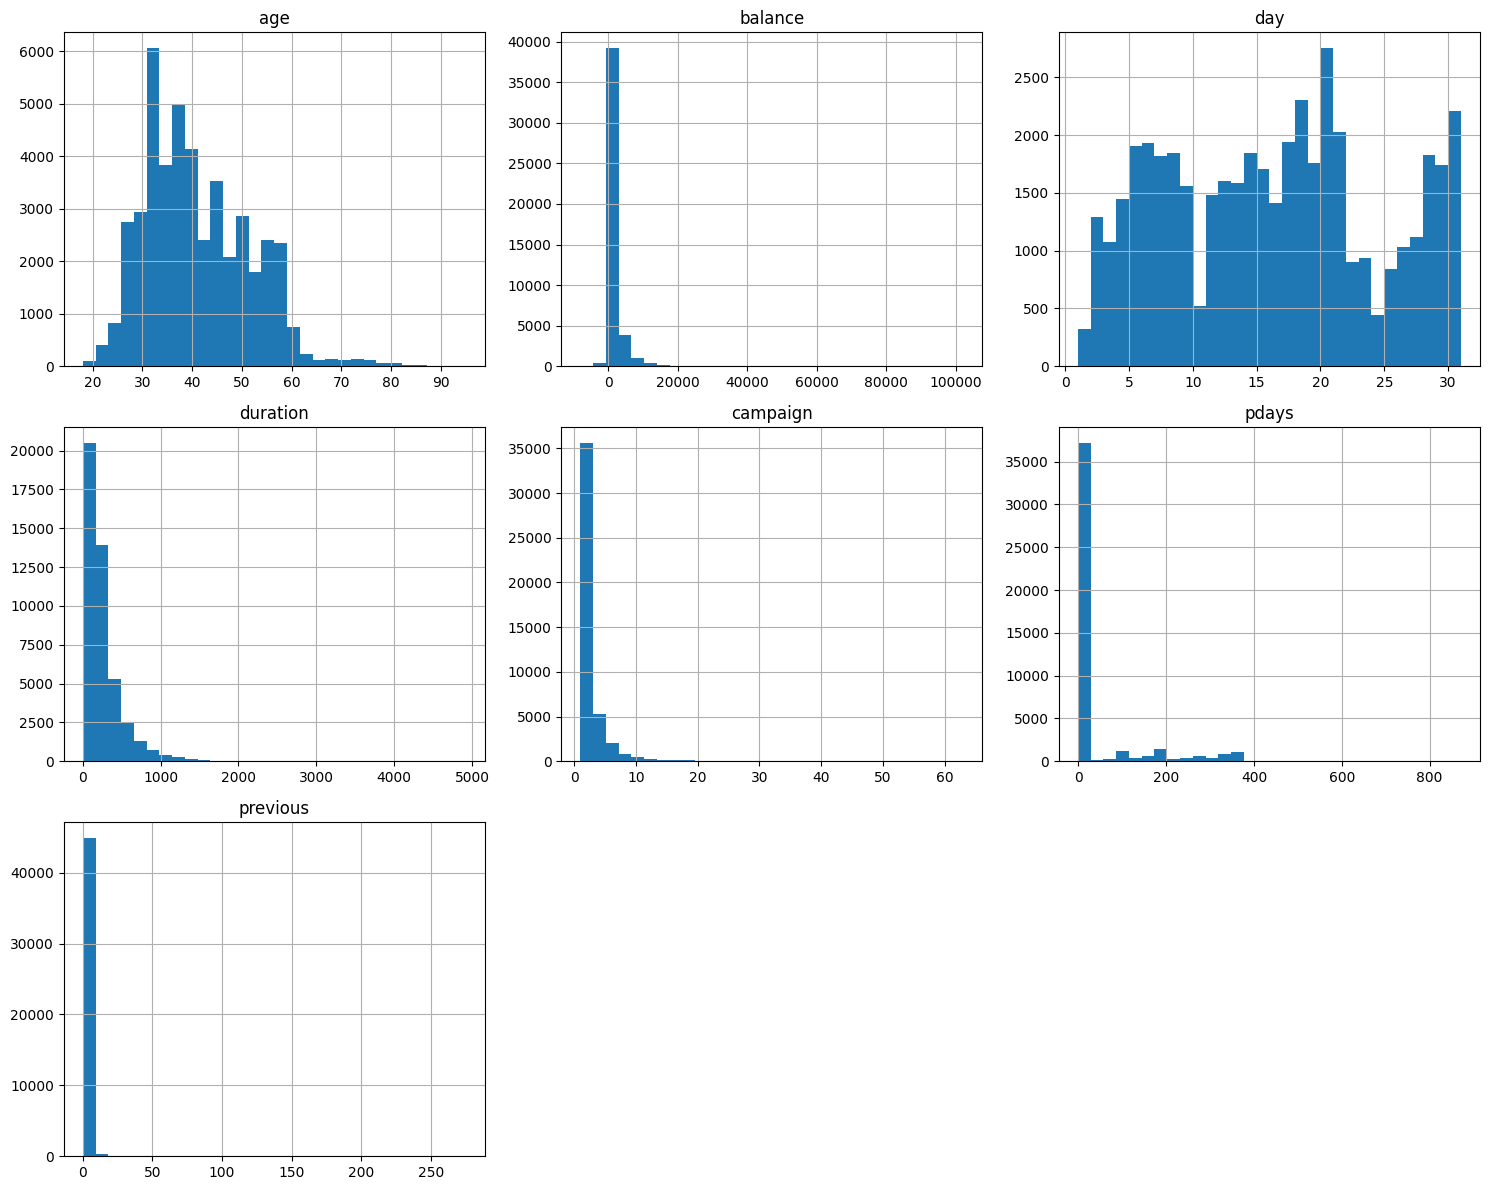

In [40]:
df[numerical_cols].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

In [41]:
skewness = df[numerical_cols].skew()

skewness.sort_values(ascending=False)

,0
previous,41.846454
balance,8.360308
campaign,4.898650
duration,3.144318
pdays,2.615715
age,0.684818
day,0.093079


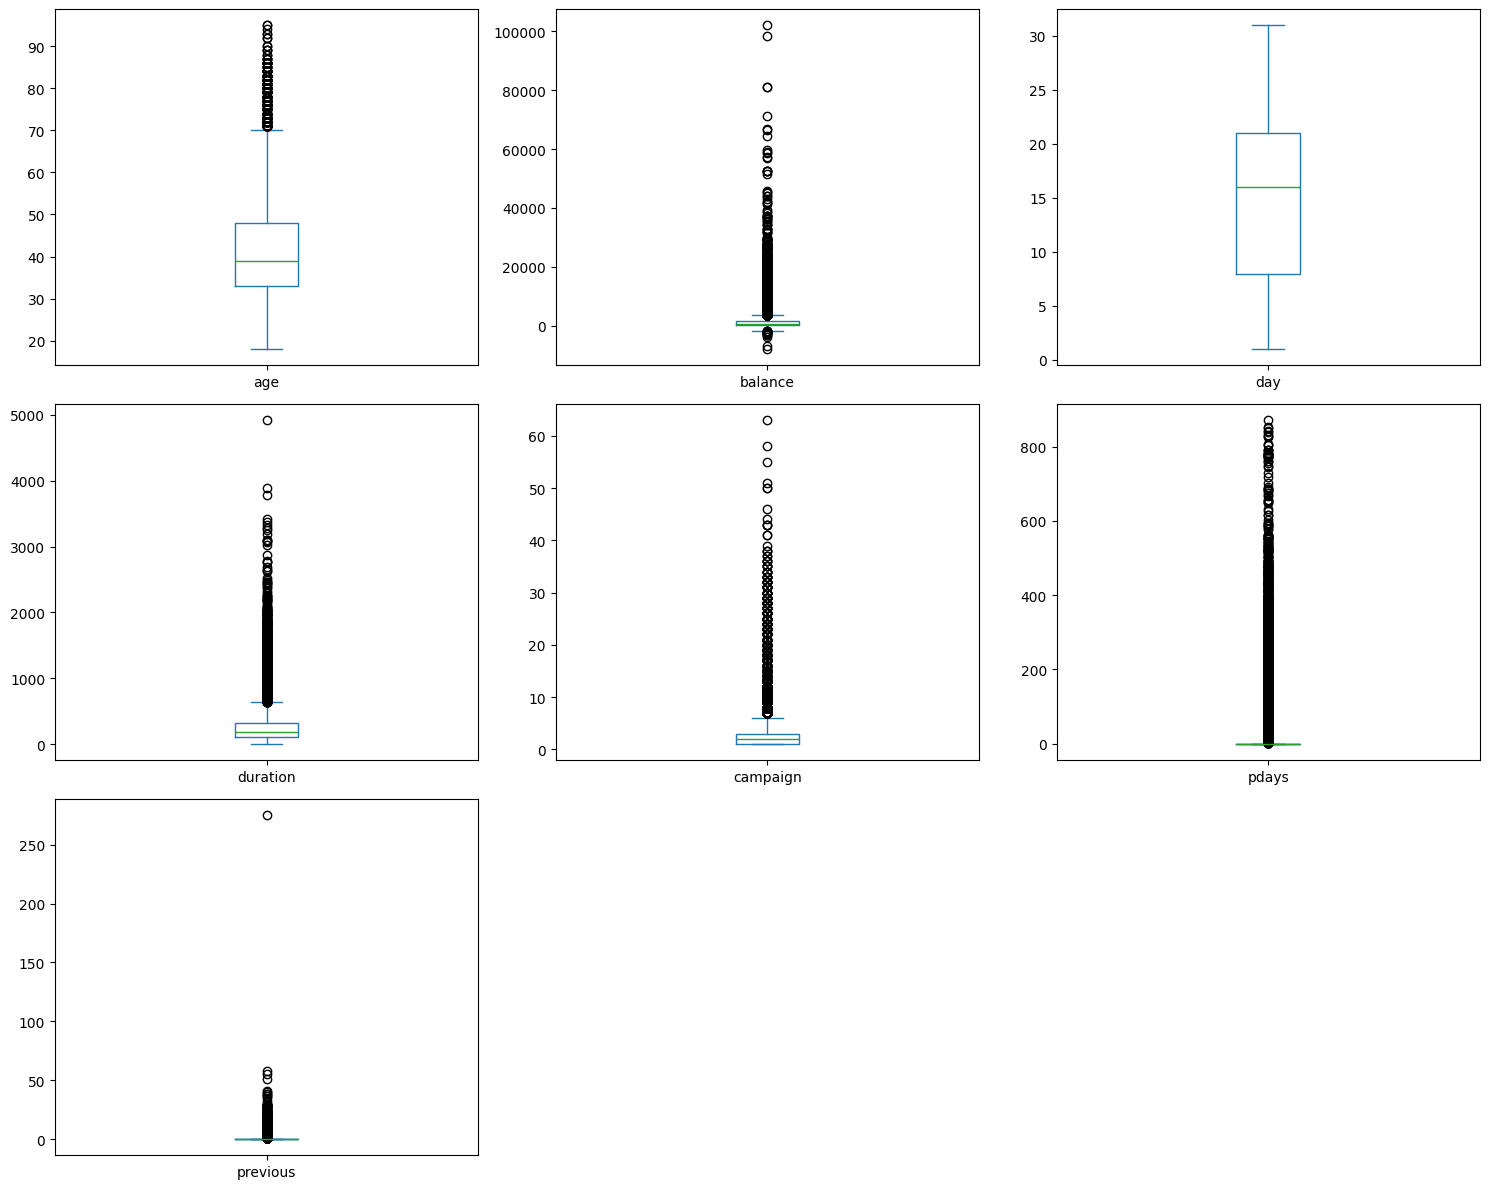

In [42]:
df[numerical_cols].plot(
    kind="box",
    subplots=True,
    layout=(3, 3),
    figsize=(15, 12)
)

plt.tight_layout()
plt.show()

In [43]:
outlier_results = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    outlier_percentage = (outlier_count / len(df)) * 100

    outlier_results.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Outlier Count": outlier_count,
        "Outlier Percentage": outlier_percentage
    })

outlier_summary = pd.DataFrame(outlier_results)

outlier_summary

,Feature,Q1,Q3,IQR,Outlier Count,Outlier Percentage
0,age,33.0,48.0,15.0,487,1.077171
1,balance,72.0,1428.0,1356.0,4729,10.459844
2,day,8.0,21.0,13.0,0,0.000000
3,duration,103.0,319.0,216.0,3235,7.155338
4,campaign,1.0,3.0,2.0,3064,6.777112
5,pdays,-1.0,-1.0,0.0,8257,18.263255
6,previous,0.0,0.0,0.0,8257,18.263255


In [44]:
categorical_cols = df.select_dtypes(include="object").columns

print("Categorical variables:")
print(categorical_cols.tolist())

Categorical variables:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


In [45]:
for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts())


===== job =====
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

===== marital =====
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

===== education =====
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

===== default =====
default
no     44396
yes      815
Name: count, dtype: int64

===== housing =====
housing
yes    25130
no     20081
Name: count, dtype: int64

===== loan =====
loan
no     37967
yes     7244
Name: count, dtype: int64

===== contact =====
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

===== month =====
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr   

In [46]:
unknown_results = []

for col in df.columns:
    count = (df[col] == "unknown").sum()

    if count > 0:
        percentage = (count / len(df)) * 100

        unknown_results.append({
            "Feature": col,
            "Unknown Count": count,
            "Unknown Percentage": percentage
        })

unknown_summary = pd.DataFrame(unknown_results)

unknown_summary

,Feature,Unknown Count,Unknown Percentage
0,job,288,0.637013
1,education,1857,4.107407
2,contact,13020,28.798301
3,poutcome,36959,81.747805


In [47]:
correlation = df[numerical_cols].corr()

correlation

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


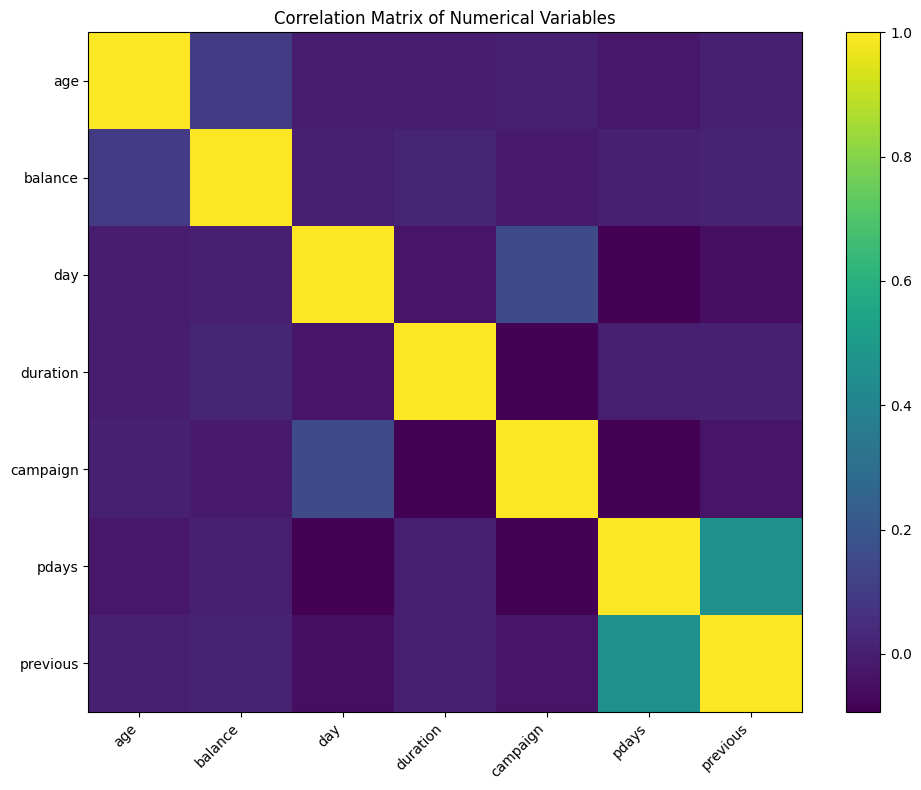

In [48]:
plt.figure(figsize=(10, 8))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()

In [49]:
job_target = pd.crosstab(
    df["job"],
    df["y"],
    normalize="index"
) * 100

job_target

y,no,yes
job,,
admin.,87.797331,12.202669
blue-collar,92.725031,7.274969
entrepreneur,91.728312,8.271688
housemaid,91.209677,8.790323
management,86.244449,13.755551
retired,77.208481,22.791519
self-employed,88.157061,11.842939
services,91.116996,8.883004
student,71.321962,28.678038


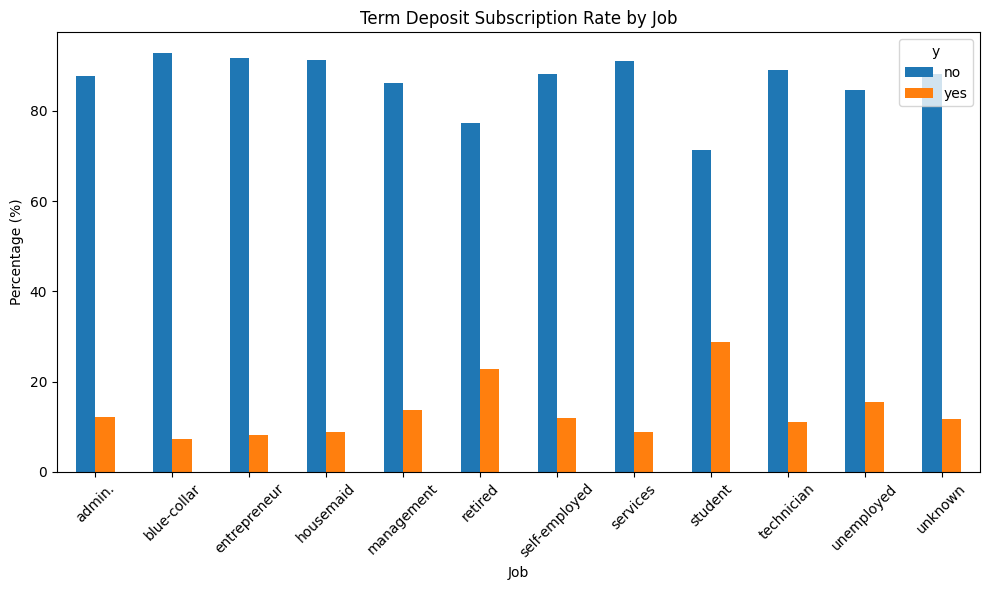

In [50]:
job_target.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Term Deposit Subscription Rate by Job")
plt.xlabel("Job")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [51]:
print("Mean values by target:")
print(df.groupby("y")[numerical_cols].mean())

print("\nMedian values by target:")
print(df.groupby("y")[numerical_cols].median())

Mean values by target:
           age      balance        day    duration  campaign      pdays  \
y                                                                         
no   40.838986  1303.714969  15.892290  221.182806  2.846350  36.421372   
yes  41.670070  1804.267915  15.158253  537.294574  2.141047  68.702968   

     previous  
y              
no   0.502154  
yes  1.170354  

Median values by target:
      age  balance   day  duration  campaign  pdays  previous
y                                                            
no   39.0    417.0  16.0     164.0       2.0   -1.0       0.0
yes  38.0    733.0  15.0     426.0       2.0   -1.0       0.0


In [52]:
for col in categorical_cols.drop("y"):
    print(f"\n===== {col} vs Subscription =====")
    print(
        pd.crosstab(
            df[col],
            df["y"],
            normalize="index"
        ) * 100
    )


===== job vs Subscription =====
y                     no        yes
job                                
admin.         87.797331  12.202669
blue-collar    92.725031   7.274969
entrepreneur   91.728312   8.271688
housemaid      91.209677   8.790323
management     86.244449  13.755551
retired        77.208481  22.791519
self-employed  88.157061  11.842939
services       91.116996   8.883004
student        71.321962  28.678038
technician     88.943004  11.056996
unemployed     84.497314  15.502686
unknown        88.194444  11.805556

===== marital vs Subscription =====
y                no        yes
marital                       
divorced  88.054542  11.945458
married   89.876534  10.123466
single    85.050821  14.949179

===== education vs Subscription =====
y                 no        yes
education                      
primary    91.373522   8.626478
secondary  89.440565  10.559435
tertiary   84.993610  15.006390
unknown    86.429725  13.570275

===== default vs Subscription =====
y  

In [53]:
for col in categorical_cols:
    print(f"\n===== {col} =====")

    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100

    summary = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages
    })

    print(summary)


===== job =====
               Count  Percentage
job                             
blue-collar     9732   21.525735
management      9458   20.919688
technician      7597   16.803433
admin.          5171   11.437482
services        4154    9.188029
retired         2264    5.007631
self-employed   1579    3.492513
entrepreneur    1487    3.289023
unemployed      1303    2.882042
housemaid       1240    2.742695
student          938    2.074716
unknown          288    0.637013

===== marital =====
          Count  Percentage
marital                    
married   27214   60.193316
single    12790   28.289576
divorced   5207   11.517109

===== education =====
           Count  Percentage
education                   
secondary  23202   51.319369
tertiary   13301   29.419831
primary     6851   15.153392
unknown     1857    4.107407

===== default =====
         Count  Percentage
default                   
no       44396   98.197341
yes        815    1.802659

===== housing =====
         Coun

<Figure size 700x500 with 0 Axes>

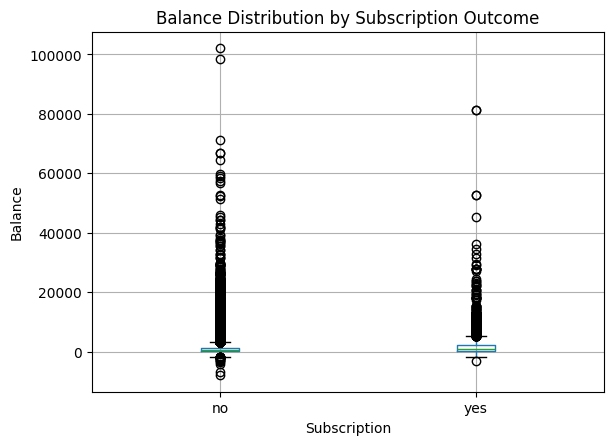

In [54]:
plt.figure(figsize=(7, 5))

df.boxplot(
    column="balance",
    by="y"
)

plt.title("Balance Distribution by Subscription Outcome")
plt.suptitle("")
plt.xlabel("Subscription")
plt.ylabel("Balance")

plt.show()

<Figure size 700x500 with 0 Axes>

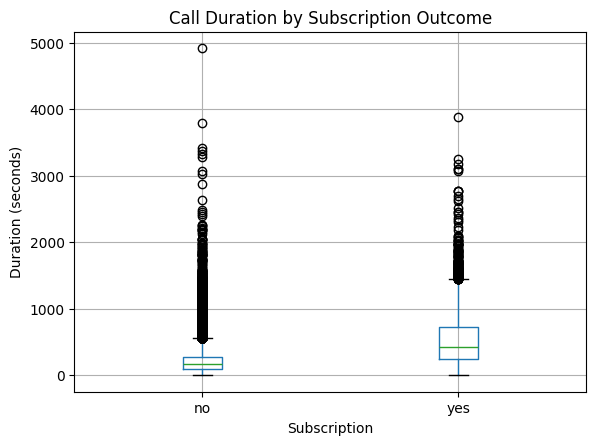

In [55]:
plt.figure(figsize=(7, 5))

df.boxplot(
    column="duration",
    by="y"
)

plt.title("Call Duration by Subscription Outcome")
plt.suptitle("")
plt.xlabel("Subscription")
plt.ylabel("Duration (seconds)")

plt.show()

<Figure size 700x500 with 0 Axes>

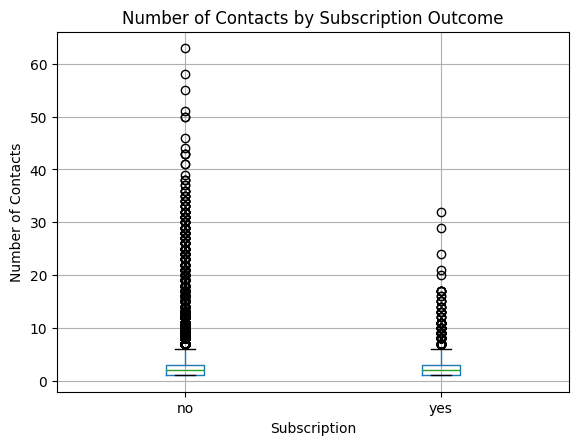

In [56]:
plt.figure(figsize=(7, 5))

df.boxplot(
    column="campaign",
    by="y"
)

plt.title("Number of Contacts by Subscription Outcome")
plt.suptitle("")
plt.xlabel("Subscription")
plt.ylabel("Number of Contacts")

plt.show()

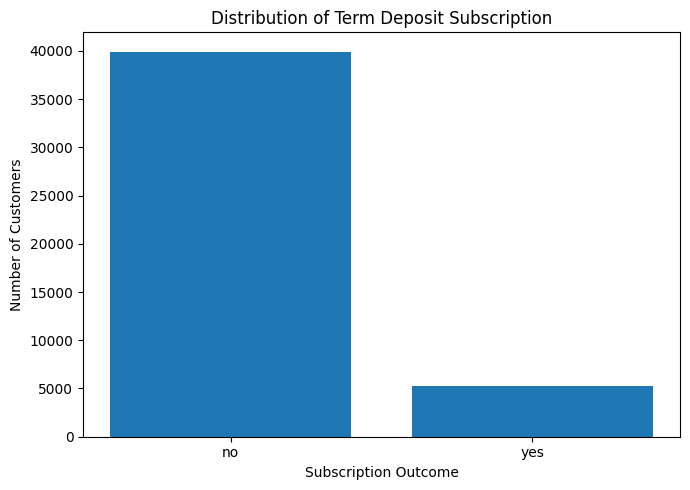

In [57]:
import matplotlib.pyplot as plt

target_counts = df["y"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(target_counts.index, target_counts.values)

plt.title("Distribution of Term Deposit Subscription")
plt.xlabel("Subscription Outcome")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

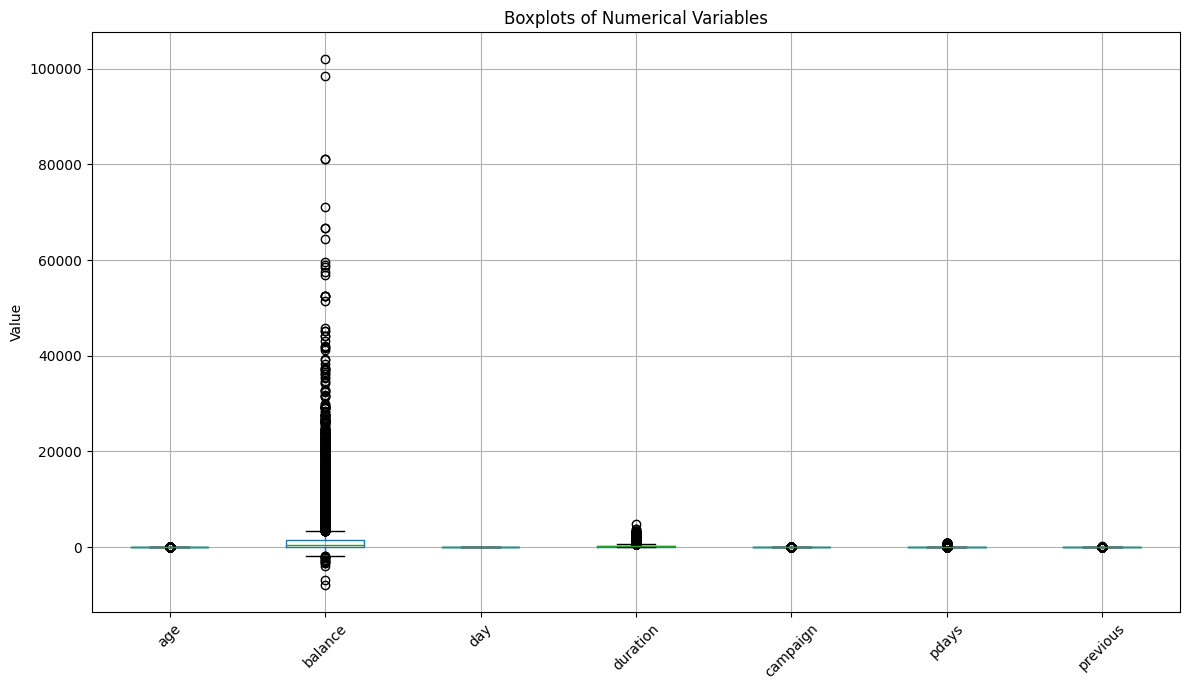

In [59]:
plt.figure(figsize=(12, 7))

df[numerical_cols].boxplot()

plt.title("Boxplots of Numerical Variables")
plt.ylabel("Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

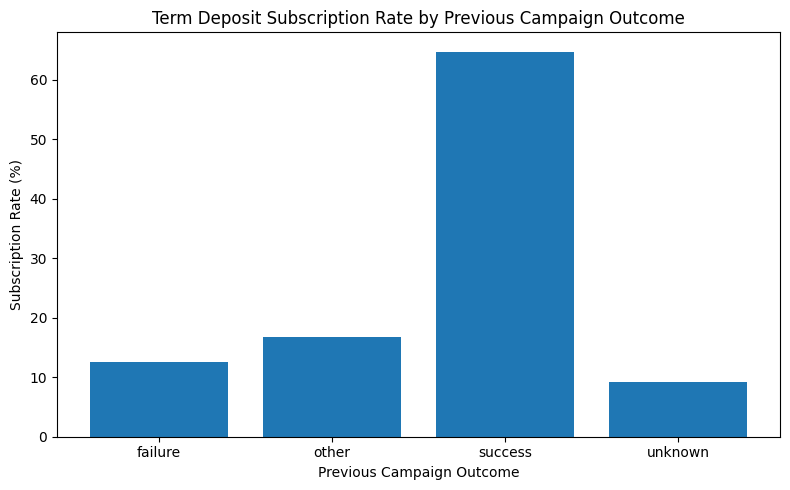

In [60]:
poutcome_rate = (
    pd.crosstab(
        df["poutcome"],
        df["y"],
        normalize="index"
    )["yes"] * 100
)

plt.figure(figsize=(8, 5))

plt.bar(poutcome_rate.index, poutcome_rate.values)

plt.title("Term Deposit Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Subscription Rate (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

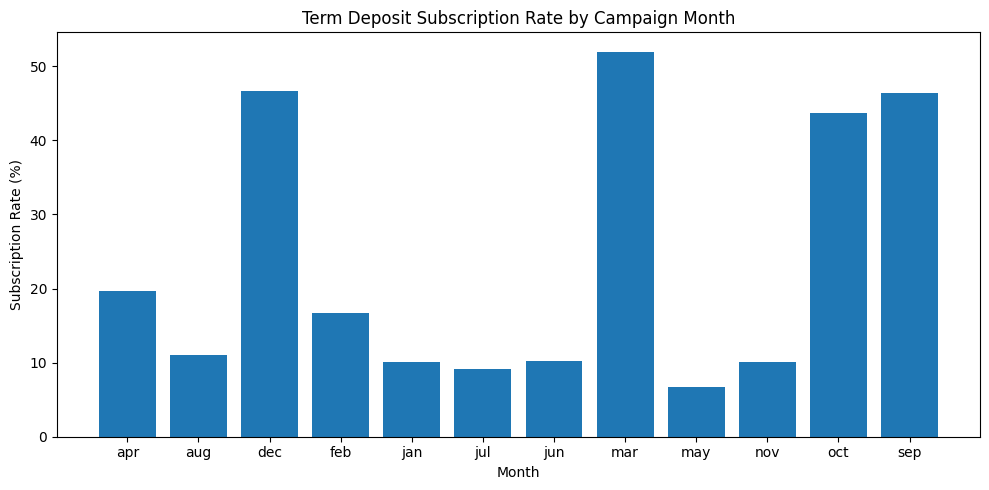

In [61]:
month_rate = (
    pd.crosstab(
        df["month"],
        df["y"],
        normalize="index"
    )["yes"] * 100
)

plt.figure(figsize=(10, 5))

plt.bar(month_rate.index, month_rate.values)

plt.title("Term Deposit Subscription Rate by Campaign Month")
plt.xlabel("Month")
plt.ylabel("Subscription Rate (%)")

plt.tight_layout()
plt.show()

In [62]:
duration_summary = df.groupby("y")["duration"].agg(
    ["count", "mean", "median", "min", "max"]
)

print(duration_summary)

     count        mean  median  min   max
y                                        
no   39922  221.182806   164.0    0  4918
yes   5289  537.294574   426.0    8  3881


In [ ]:
# Task 4

In [63]:
df_clean = df.copy()

print("Original shape:", df_clean.shape)

Original shape: (45211, 17)


In [64]:
df_clean["y"] = df_clean["y"].map({
    "no": 0,
    "yes": 1
})

print(df_clean["y"].value_counts())

y
0    39922
1     5289
Name: count, dtype: int64


In [65]:
df_model = df_clean.drop(columns=["duration"])

print("Shape after removing duration:", df_model.shape)

Shape after removing duration: (45211, 16)


In [66]:
X = df_model.drop(columns=["y"])
y = df_model["y"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (45211, 15)
y shape: (45211,)


In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set: (36168, 15)
Testing set: (9043, 15)

Training target distribution:
y
0    88.301814
1    11.698186
Name: proportion, dtype: float64

Testing target distribution:
y
0    88.300343
1    11.699657
Name: proportion, dtype: float64


In [68]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [69]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [70]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (36168, 50)
Processed testing shape: (9043, 50)


In [71]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTraining class percentages:")
print(y_train.value_counts(normalize=True) * 100)

Training class distribution:
y
0    31937
1     4231
Name: count, dtype: int64

Training class percentages:
y
0    88.301814
1    11.698186
Name: proportion, dtype: float64


In [ ]:
# Step 5 — Evaluate class balancing

In [72]:
from imblearn.over_sampling import RandomOverSampler, SMOTE

In [73]:
print("Before balancing:")
print(y_train.value_counts())

print("\nPercentages:")
print(y_train.value_counts(normalize=True) * 100)

Before balancing:
y
0    31937
1     4231
Name: count, dtype: int64

Percentages:
y
0    88.301814
1    11.698186
Name: proportion, dtype: float64


In [74]:
ros = RandomOverSampler(random_state=42)

X_train_ros, y_train_ros = ros.fit_resample(
    X_train_processed,
    y_train
)

print("After Random Oversampling:")
print(y_train_ros.value_counts())

print("\nPercentages:")
print(y_train_ros.value_counts(normalize=True) * 100)

After Random Oversampling:
y
0    31937
1    31937
Name: count, dtype: int64

Percentages:
y
0    50.0
1    50.0
Name: proportion, dtype: float64


In [75]:
# SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("After SMOTE:")
print(y_train_smote.value_counts())

print("\nPercentages:")
print(y_train_smote.value_counts(normalize=True) * 100)

After SMOTE:
y
0    31937
1    31937
Name: count, dtype: int64

Percentages:
y
0    50.0
1    50.0
Name: proportion, dtype: float64


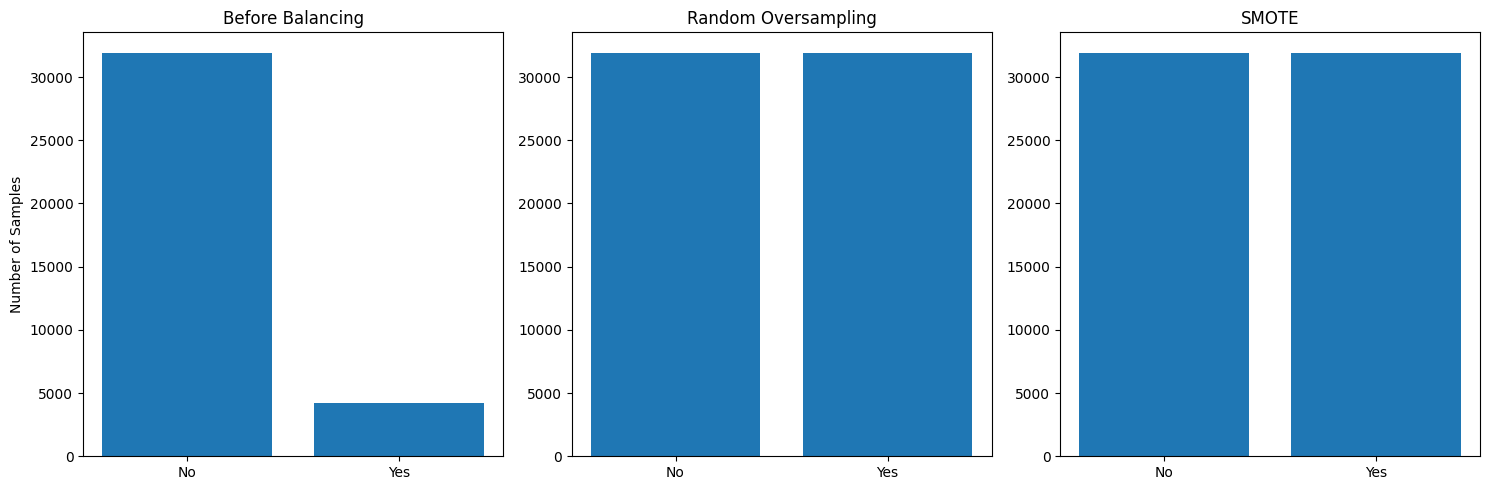

In [76]:
import matplotlib.pyplot as plt

before = y_train.value_counts()
after_ros = y_train_ros.value_counts()
after_smote = y_train_smote.value_counts()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(
    ["No", "Yes"],
    [before[0], before[1]]
)
axes[0].set_title("Before Balancing")
axes[0].set_ylabel("Number of Samples")

axes[1].bar(
    ["No", "Yes"],
    [after_ros[0], after_ros[1]]
)
axes[1].set_title("Random Oversampling")

axes[2].bar(
    ["No", "Yes"],
    [after_smote[0], after_smote[1]]
)
axes[2].set_title("SMOTE")

plt.tight_layout()
plt.show()

In [77]:
# Results
print("Before:", y_train.value_counts().to_dict())
print("Random Oversampling:", y_train_ros.value_counts().to_dict())
print("SMOTE:", y_train_smote.value_counts().to_dict())

Before: {0: 31937, 1: 4231}
Random Oversampling: {0: 31937, 1: 31937}
SMOTE: {0: 31937, 1: 31937}


In [78]:
# Train the three models
from sklearn.linear_model import LogisticRegression

# Model 1: No balancing
model_baseline = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_baseline.fit(X_train_processed, y_train)


# Model 2: Random Oversampling
model_ros = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_ros.fit(X_train_ros, y_train_ros)


# Model 3: SMOTE
model_smote = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_smote.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000, random_state=42)

In [79]:
# Evaluate all three models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Baseline": model_baseline,
    "Random Oversampling": model_ros,
    "SMOTE": model_smote
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    results.append({
        "Method": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

print(results_df.round(4))

                Method  Accuracy  Precision  Recall  F1-score  ROC-AUC
0             Baseline    0.8933     0.6632  0.1786    0.2815   0.7717
1  Random Oversampling    0.7566     0.2680  0.6238    0.3749   0.7712
2                SMOTE    0.7467     0.2606  0.6342    0.3694   0.7668


In [ ]:
# Evaluate skewed numerical features

In [80]:
skewed_features = [
    "balance",
    "campaign",
    "previous",
    "pdays"
]

print(df_model[skewed_features].describe())

             balance      campaign      previous         pdays
count   45211.000000  45211.000000  45211.000000  45211.000000
mean     1362.272058      2.763841      0.580323     40.197828
std      3044.765829      3.098021      2.303441    100.128746
min     -8019.000000      1.000000      0.000000     -1.000000
25%        72.000000      1.000000      0.000000     -1.000000
50%       448.000000      2.000000      0.000000     -1.000000
75%      1428.000000      3.000000      0.000000     -1.000000
max    102127.000000     63.000000    275.000000    871.000000


In [81]:
print("\nMinimum values:")
print(df_model[skewed_features].min())


Minimum values:
balance    -8019
campaign       1
previous       0
pdays         -1
dtype: int64


In [82]:
original_skewness = df_model[skewed_features].skew()

print("Original skewness:")
print(original_skewness)

Original skewness:
balance      8.360308
campaign     4.898650
previous    41.846454
pdays        2.615715
dtype: float64


In [83]:
df_log = df_model.copy()

df_log["campaign"] = np.log1p(df_log["campaign"])
df_log["previous"] = np.log1p(df_log["previous"])

print("Skewness after log transformation:")
print(df_log[["campaign", "previous"]].skew())

Skewness after log transformation:
campaign    1.326222
previous    2.516166
dtype: float64


In [84]:
print("Minimum balance:", df_model["balance"].min())
print("Negative balances:", (df_model["balance"] < 0).sum())

Minimum balance: -8019
Negative balances: 3766


In [85]:
from sklearn.preprocessing import PowerTransformer

yj = PowerTransformer(
    method="yeo-johnson",
    standardize=False
)

df_yj = df_model.copy()

df_yj[skewed_features] = yj.fit_transform(
    df_model[skewed_features]
)

print("Skewness after Yeo-Johnson:")
print(df_yj[skewed_features].skew())

Skewness after Yeo-Johnson:
balance     1.098582
campaign    0.230942
previous    1.646051
pdays       1.645213
dtype: float64


In [86]:
comparison = pd.DataFrame({
    "Original": df_model[skewed_features].skew(),
    "Yeo-Johnson": df_yj[skewed_features].skew()
})

comparison["Absolute Skew Reduction"] = (
    comparison["Original"].abs()
    - comparison["Yeo-Johnson"].abs()
)

print(comparison.round(3))

          Original  Yeo-Johnson  Absolute Skew Reduction
balance      8.360        1.099                    7.262
campaign     4.899        0.231                    4.668
previous    41.846        1.646                   40.200
pdays        2.616        1.645                    0.971


In [87]:
log_comparison = pd.DataFrame({
    "Original": df_model[["campaign", "previous"]].skew(),
    "Log_Transformed": df_log[["campaign", "previous"]].skew(),
    "Yeo_Johnson": df_yj[["campaign", "previous"]].skew()
})

print(log_comparison.round(3))

          Original  Log_Transformed  Yeo_Johnson
campaign     4.899            1.326        0.231
previous    41.846            2.516        1.646


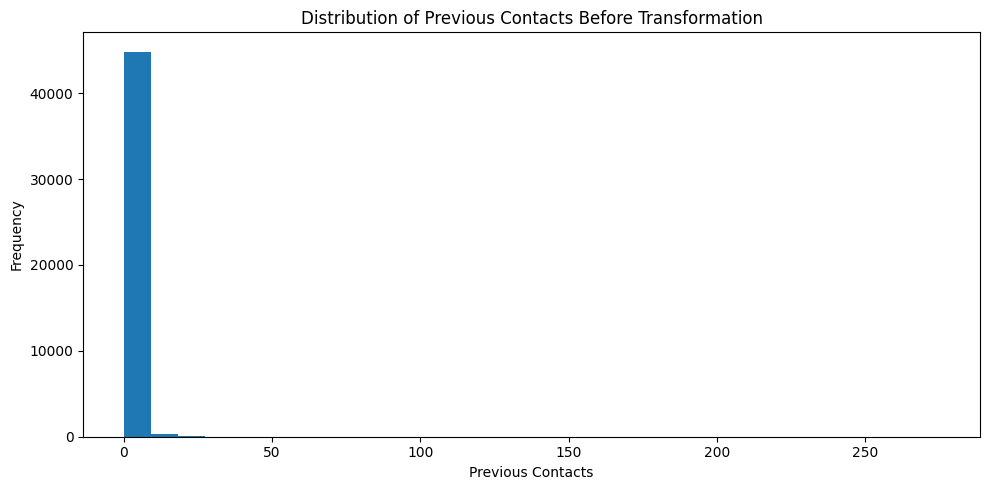

In [88]:
plt.figure(figsize=(10, 5))

plt.hist(df_model["previous"], bins=30)

plt.title("Distribution of Previous Contacts Before Transformation")
plt.xlabel("Previous Contacts")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

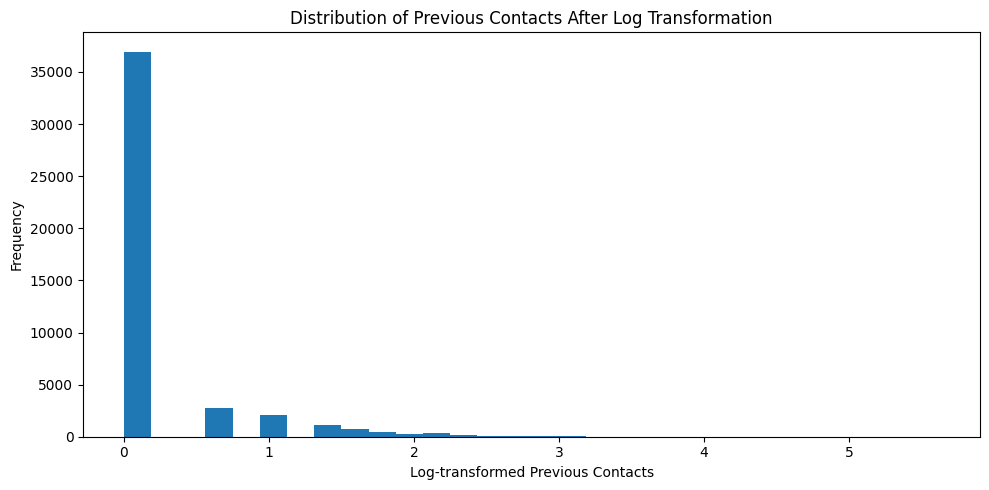

In [89]:
plt.figure(figsize=(10, 5))

plt.hist(df_log["previous"], bins=30)

plt.title("Distribution of Previous Contacts After Log Transformation")
plt.xlabel("Log-transformed Previous Contacts")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

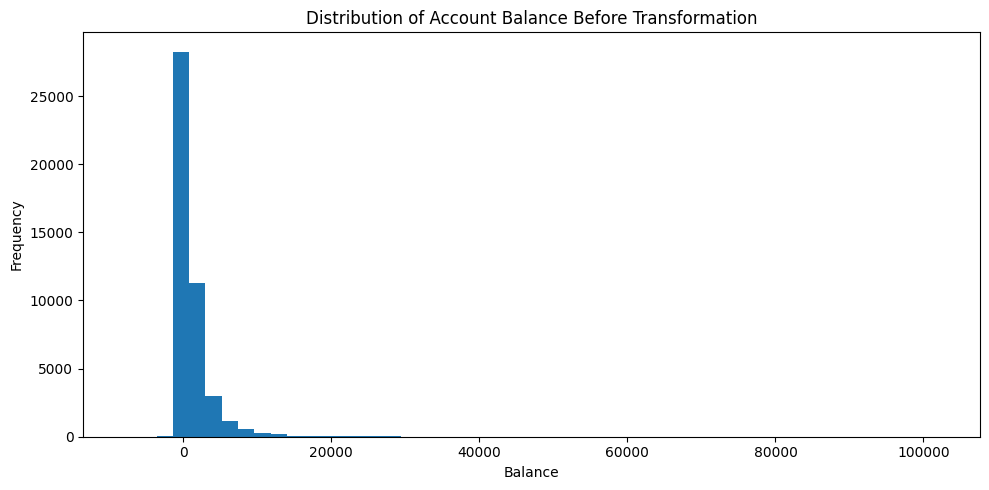

In [90]:
plt.figure(figsize=(10, 5))

plt.hist(df_model["balance"], bins=50)

plt.title("Distribution of Account Balance Before Transformation")
plt.xlabel("Balance")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

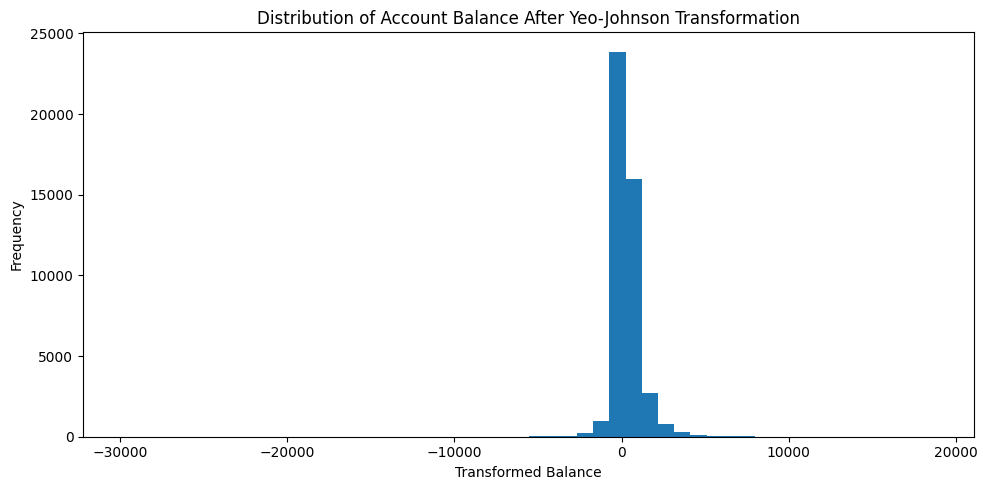

In [91]:
plt.figure(figsize=(10, 5))

plt.hist(df_yj["balance"], bins=50)

plt.title("Distribution of Account Balance After Yeo-Johnson Transformation")
plt.xlabel("Transformed Balance")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [92]:
print(df_model["pdays"].value_counts().head(10))

pdays
-1      36954
 182      167
 92       147
 183      126
 91       126
 181      117
 370       99
 184       85
 364       77
 95        74
Name: count, dtype: int64


In [93]:
df_model["previously_contacted"] = (
    df_model["pdays"] != -1
).astype(int)

In [94]:
print(
    df_model["previously_contacted"].value_counts()
)

previously_contacted
0    36954
1     8257
Name: count, dtype: int64


In [95]:
print(df_model[skewed_features].min())

balance    -8019
campaign       1
previous       0
pdays         -1
dtype: int64


In [96]:
print(log_comparison.round(3))

          Original  Log_Transformed  Yeo_Johnson
campaign     4.899            1.326        0.231
previous    41.846            2.516        1.646


In [97]:
print(comparison.round(3))

          Original  Yeo-Johnson  Absolute Skew Reduction
balance      8.360        1.099                    7.262
campaign     4.899        0.231                    4.668
previous    41.846        1.646                   40.200
pdays        2.616        1.645                    0.971


In [98]:
print(df_model["pdays"].value_counts().head(10))

pdays
-1      36954
 182      167
 92       147
 183      126
 91       126
 181      117
 370       99
 184       85
 364       77
 95        74
Name: count, dtype: int64


In [101]:
df_model["previously_contacted"] = (
    df_model["pdays"] != -1
).astype(int)

In [102]:
df_model["days_since_previous_contact"] = df_model["pdays"].replace(-1, np.nan)

In [103]:
from sklearn.preprocessing import PowerTransformer

numerical_pipeline_yj = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(
        method="yeo-johnson",
        standardize=True
    ))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_yj = ColumnTransformer([
    ("num", numerical_pipeline_yj, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [104]:
X_train_yj = preprocessor_yj.fit_transform(X_train)
X_test_yj = preprocessor_yj.transform(X_test)

print("Yeo-Johnson training shape:", X_train_yj.shape)
print("Yeo-Johnson testing shape:", X_test_yj.shape)

Yeo-Johnson training shape: (36168, 50)
Yeo-Johnson testing shape: (9043, 50)


In [105]:
model_yj = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_yj.fit(X_train_yj, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [106]:
y_pred_yj = model_yj.predict(X_test_yj)
y_prob_yj = model_yj.predict_proba(X_test_yj)[:, 1]

yj_results = {
    "Accuracy": accuracy_score(y_test, y_pred_yj),
    "Precision": precision_score(y_test, y_pred_yj),
    "Recall": recall_score(y_test, y_pred_yj),
    "F1-score": f1_score(y_test, y_pred_yj),
    "ROC-AUC": roc_auc_score(y_test, y_prob_yj)
}

print(pd.Series(yj_results).round(4))

Accuracy     0.8938
Precision    0.6725
Recall       0.1805
F1-score     0.2846
ROC-AUC      0.7721
dtype: float64


In [ ]:
# Standardisation vs Normalisation

In [107]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Standardisation pipeline
numerical_standard = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor_standard = ColumnTransformer([
    ("num", numerical_standard, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])


# Normalisation pipeline
numerical_minmax = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

preprocessor_minmax = ColumnTransformer([
    ("num", numerical_minmax, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [108]:
X_train_standard = preprocessor_standard.fit_transform(X_train)
X_test_standard = preprocessor_standard.transform(X_test)

X_train_minmax = preprocessor_minmax.fit_transform(X_train)
X_test_minmax = preprocessor_minmax.transform(X_test)

print("Standardisation:")
print("Training:", X_train_standard.shape)
print("Testing:", X_test_standard.shape)

print("\nNormalisation:")
print("Training:", X_train_minmax.shape)
print("Testing:", X_test_minmax.shape)

Standardisation:
Training: (36168, 50)
Testing: (9043, 50)

Normalisation:
Training: (36168, 50)
Testing: (9043, 50)


In [109]:
model_standard = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_minmax = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_standard.fit(X_train_standard, y_train)
model_minmax.fit(X_train_minmax, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [110]:
y_pred_standard = model_standard.predict(X_test_standard)
y_prob_standard = model_standard.predict_proba(X_test_standard)[:, 1]

y_pred_minmax = model_minmax.predict(X_test_minmax)
y_prob_minmax = model_minmax.predict_proba(X_test_minmax)[:, 1]


standard_results = {
    "Method": "Standardisation",
    "Accuracy": accuracy_score(y_test, y_pred_standard),
    "Precision": precision_score(y_test, y_pred_standard),
    "Recall": recall_score(y_test, y_pred_standard),
    "F1-score": f1_score(y_test, y_pred_standard),
    "ROC-AUC": roc_auc_score(y_test, y_prob_standard)
}

minmax_results = {
    "Method": "Normalisation",
    "Accuracy": accuracy_score(y_test, y_pred_minmax),
    "Precision": precision_score(y_test, y_pred_minmax),
    "Recall": recall_score(y_test, y_pred_minmax),
    "F1-score": f1_score(y_test, y_pred_minmax),
    "ROC-AUC": roc_auc_score(y_test, y_prob_minmax)
}

scaling_results = pd.DataFrame([
    standard_results,
    minmax_results
])

print(scaling_results.round(4))

            Method  Accuracy  Precision  Recall  F1-score  ROC-AUC
0  Standardisation    0.8933     0.6632  0.1786    0.2815   0.7717
1    Normalisation    0.8928     0.6572  0.1758    0.2774   0.7718


In [111]:
# Evaluate PCA
from sklearn.decomposition import PCA

In [112]:
pca_95 = PCA(
    n_components=0.95,
    random_state=42
)

X_train_pca = pca_95.fit_transform(X_train_standard)
X_test_pca = pca_95.transform(X_test_standard)

print("Original number of features:", X_train_standard.shape[1])
print("PCA components:", X_train_pca.shape[1])
print("Explained variance:", pca_95.explained_variance_ratio_.sum())

Original number of features: 50
PCA components: 24
Explained variance: 0.9542637498656604


In [113]:
model_pca = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_pca.fit(X_train_pca, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [114]:
y_pred_pca = model_pca.predict(X_test_pca)
y_prob_pca = model_pca.predict_proba(X_test_pca)[:, 1]

pca_results = {
    "Method": "Standardisation + PCA",
    "Accuracy": accuracy_score(y_test, y_pred_pca),
    "Precision": precision_score(y_test, y_pred_pca),
    "Recall": recall_score(y_test, y_pred_pca),
    "F1-score": f1_score(y_test, y_pred_pca),
    "ROC-AUC": roc_auc_score(y_test, y_prob_pca)
}

print(pd.Series(pca_results).round(4))

Method       Standardisation + PCA
Accuracy                  0.883556
Precision                 0.553191
Recall                    0.024575
F1-score                  0.047059
ROC-AUC                   0.745072
dtype: object


In [115]:
pca_comparison = pd.DataFrame([
    {
        "Method": "Standardisation",
        "Features": X_train_standard.shape[1],
        "Accuracy": accuracy_score(y_test, y_pred_standard),
        "Precision": precision_score(y_test, y_pred_standard),
        "Recall": recall_score(y_test, y_pred_standard),
        "F1-score": f1_score(y_test, y_pred_standard),
        "ROC-AUC": roc_auc_score(y_test, y_prob_standard)
    },
    {
        "Method": "Standardisation + PCA",
        "Features": X_train_pca.shape[1],
        "Accuracy": accuracy_score(y_test, y_pred_pca),
        "Precision": precision_score(y_test, y_pred_pca),
        "Recall": recall_score(y_test, y_pred_pca),
        "F1-score": f1_score(y_test, y_pred_pca),
        "ROC-AUC": roc_auc_score(y_test, y_prob_pca)
    }
])

print(pca_comparison.round(4))

                  Method  Features  Accuracy  Precision  Recall  F1-score  \
0        Standardisation        50    0.8933     0.6632  0.1786    0.2815   
1  Standardisation + PCA        24    0.8836     0.5532  0.0246    0.0471   

   ROC-AUC  
0   0.7717  
1   0.7451  


In [116]:
X = df.drop(columns=["y", "duration"])

y = df["y"].map({
    "no": 0,
    "yes": 1
})

In [117]:
X["previously_contacted"] = (
    X["pdays"] != -1
).astype(int)

In [118]:
print("X shape:", X.shape)
print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

X shape: (45211, 16)

Features:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome', 'previously_contacted']

Target distribution:
y
0    39922
1     5289
Name: count, dtype: int64


In [119]:
from sklearn.model_selection import train_test_split

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train_final.shape)
print("Testing shape:", X_test_final.shape)

print("\nTraining target:")
print(y_train_final.value_counts())

print("\nTesting target:")
print(y_test_final.value_counts())

Training shape: (36168, 16)
Testing shape: (9043, 16)

Training target:
y
0    31937
1     4231
Name: count, dtype: int64

Testing target:
y
0    7985
1    1058
Name: count, dtype: int64


In [120]:
numerical_features_final = X_train_final.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features_final = X_train_final.select_dtypes(
    include="object"
).columns.tolist()

print("Numerical features:")
print(numerical_features_final)

print("\nCategorical features:")
print(categorical_features_final)

Numerical features:
['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'previously_contacted']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [121]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    PowerTransformer,
    StandardScaler
)

numerical_pipeline_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("yeo_johnson", PowerTransformer(
        method="yeo-johnson",
        standardize=False
    )),
    ("scaler", StandardScaler())
])

categorical_pipeline_final = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_final = ColumnTransformer([
    ("num", numerical_pipeline_final, numerical_features_final),
    ("cat", categorical_pipeline_final, categorical_features_final)
])

In [122]:
X_train_processed = preprocessor_final.fit_transform(
    X_train_final
)

X_test_processed = preprocessor_final.transform(
    X_test_final
)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (36168, 51)
Processed testing shape: (9043, 51)


In [123]:
from sklearn.linear_model import LogisticRegression

final_model_baseline = LogisticRegression(
    max_iter=1000,
    random_state=42
)

final_model_baseline.fit(
    X_train_processed,
    y_train_final
)

LogisticRegression(max_iter=1000, random_state=42)

In [124]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred_final = final_model_baseline.predict(
    X_test_processed
)

y_prob_final = final_model_baseline.predict_proba(
    X_test_processed
)[:, 1]

final_baseline_results = {
    "Accuracy": accuracy_score(
        y_test_final,
        y_pred_final
    ),
    "Precision": precision_score(
        y_test_final,
        y_pred_final
    ),
    "Recall": recall_score(
        y_test_final,
        y_pred_final
    ),
    "F1-score": f1_score(
        y_test_final,
        y_pred_final
    ),
    "ROC-AUC": roc_auc_score(
        y_test_final,
        y_prob_final
    )
}

print(
    pd.Series(final_baseline_results).round(4)
)

Accuracy     0.8938
Precision    0.6750
Recall       0.1786
F1-score     0.2825
ROC-AUC      0.7722
dtype: float64


In [125]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(
    random_state=42
)

X_train_ros, y_train_ros = ros.fit_resample(
    X_train_processed,
    y_train_final
)

print("Before:", y_train_final.value_counts().to_dict())
print("After:", y_train_ros.value_counts().to_dict())

Before: {0: 31937, 1: 4231}
After: {0: 31937, 1: 31937}


In [126]:
final_model_ros = LogisticRegression(
    max_iter=1000,
    random_state=42
)

final_model_ros.fit(
    X_train_ros,
    y_train_ros
)

LogisticRegression(max_iter=1000, random_state=42)

In [127]:
y_pred_ros = final_model_ros.predict(
    X_test_processed
)

y_prob_ros = final_model_ros.predict_proba(
    X_test_processed
)[:, 1]

final_ros_results = {
    "Accuracy": accuracy_score(
        y_test_final,
        y_pred_ros
    ),
    "Precision": precision_score(
        y_test_final,
        y_pred_ros
    ),
    "Recall": recall_score(
        y_test_final,
        y_pred_ros
    ),
    "F1-score": f1_score(
        y_test_final,
        y_pred_ros
    ),
    "ROC-AUC": roc_auc_score(
        y_test_final,
        y_prob_ros
    )
}

print(
    pd.Series(final_ros_results).round(4)
)

Accuracy     0.7606
Precision    0.2740
Recall       0.6342
F1-score     0.3827
ROC-AUC      0.7713
dtype: float64
